/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_3879/477047680.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_3879/477047680.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_3879/477047680.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

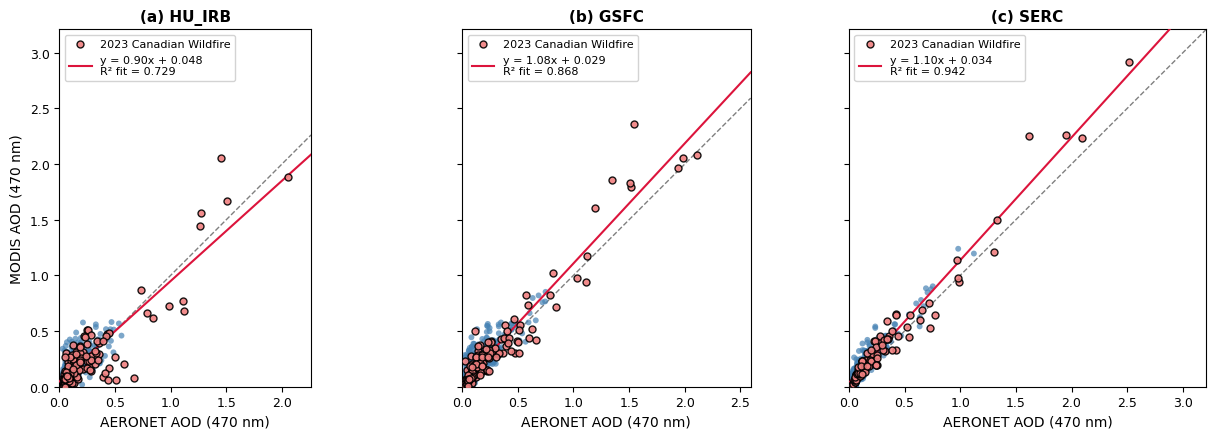

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

STATIONS = ["HU_IRB", "GSFC", "SERC"]
LABELS = ["(a)", "(b)", "(c)"]
FILL_VALUE = -999

modis = pd.read_csv("../data/MODIS_AOD_Extraction.csv", parse_dates=["datetime"])
modis = modis.dropna(subset=["AOD_470"]).sort_values("datetime")
modis["AOD_470"] /= 1000

matched_data = []

for site in STATIONS:
    ae = pd.read_csv(f"../data/{site}/{site}_AOD20_combined.csv", low_memory=False)
    
    ae["datetime"] = pd.to_datetime(
        ae["Date(dd:mm:yyyy)"] + " " + ae["Time(hh:mm:ss)"], 
        format="%d:%m:%Y %H:%M:%S"
    )
    
    cols_to_keep = ["datetime", "AOD_440nm", "440-675_Angstrom_Exponent"]
    ae = ae[cols_to_keep].replace(FILL_VALUE, np.nan).dropna()
    ae = ae[ae["datetime"].dt.year.between(2021, 2025)]
    
    ae["AOD_470"] = ae["AOD_440nm"] * ((470 / 440) ** -ae["440-675_Angstrom_Exponent"])
    
    ae_hourly = (
        ae.groupby(ae["datetime"].dt.floor("1h"))["AOD_470"]
        .mean()
        .reset_index()
    )
    
    modis_site = modis[modis["station"] == site].sort_values("datetime")
    ae_hourly = ae_hourly.sort_values("datetime")
    
    merged = pd.merge_asof(
        modis_site,
        ae_hourly,
        on="datetime",
        suffixes=("_modis", "_aeronet"),
        direction="nearest",
        tolerance=pd.Timedelta(minutes=60)
    )
    merged["station"] = site
    matched_data.append(merged)

df_all = pd.concat(matched_data, ignore_index=True).dropna(subset=["AOD_470_modis", "AOD_470_aeronet"])

highlight_start = pd.Timestamp("2023-03-01")
highlight_end = pd.Timestamp("2023-09-30")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

for ax, site, label in zip(axes, STATIONS, LABELS):
    sub = df_all[df_all["station"] == site]
    
    mask = sub["datetime"].between(highlight_start, highlight_end)
    sub_high = sub[mask]
    sub_norm = sub[~mask]
    
    x = sub["AOD_470_aeronet"].values
    y = sub["AOD_470_modis"].values

    ax.scatter(sub_norm["AOD_470_aeronet"], sub_norm["AOD_470_modis"], s=18, color="steelblue", alpha=0.7, edgecolors="none", zorder=2)
    
    ax.scatter(sub_high["AOD_470_aeronet"], sub_high["AOD_470_modis"], s=25, color="lightcoral", alpha=0.9, edgecolors="black", zorder=4, label="2023 Canadian Wildfire")

    if len(x) > 0:
        lim = max(x.max(), y.max()) * 1.1
        ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.5, zorder=1)
        ax.set_xlim(left=0, right=lim)
        ax.set_ylim(bottom=0, top=lim)

    if len(x) >= 2:
        slope, intercept, r_value, _, _ = stats.linregress(x, y)
        
        x_fit = np.linspace(0, lim, 200)
        legend_text = f"y = {slope:.2f}x + {intercept:.3f}\nR² fit = {r_value**2:.3f}"
        
        ax.plot(x_fit, slope * x_fit + intercept, color="crimson", linewidth=1.5, zorder=3, label=legend_text)
        ax.legend(fontsize=8, frameon=True, framealpha=0.85, loc="upper left")

    ax.set_xlabel("AERONET AOD (470 nm)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("MODIS AOD (470 nm)", fontsize=10)
        
    ax.set_title(f"{label} {site}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig("../data/MODIS_AERONET_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

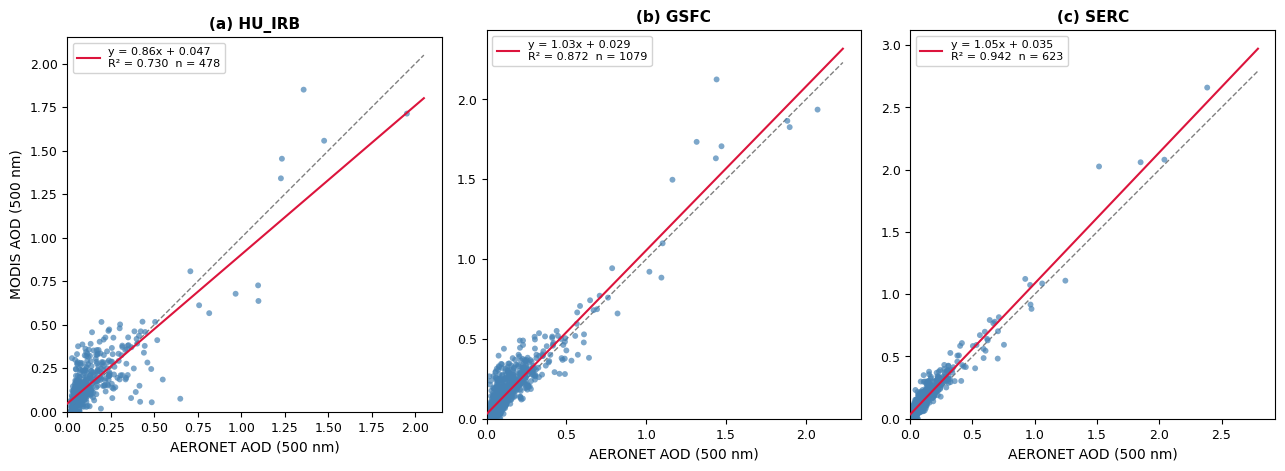

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

stations = ["HU_IRB", "GSFC", "SERC"]
labels   = ["(a)", "(b)", "(c)"]

# ── 1. Load MODIS (already converted to 500 nm) ──────────────────────────────
modis = pd.read_csv("../data/MODIS_AOD_Extraction_500nm.csv", parse_dates=["datetime"])
modis = modis.dropna(subset=["MODIS_AOD_500"]).sort_values("datetime")

# ── 2. Match to AERONET hourly average per site ──────────────────────────────
matched = []

for site in stations:
    aeronet = pd.read_csv(f"../data/{site}_AOD500_preprocessed.csv", parse_dates=["datetime"])
    aeronet = aeronet.dropna(subset=["AOD_500nm"]).sort_values("datetime")
    aeronet = aeronet[aeronet["datetime"].dt.year.between(2021, 2025)]

    # Hourly average of AERONET
    aeronet["hour"] = aeronet["datetime"].dt.floor("1h")
    aeronet_hourly = (
        aeronet.groupby("hour")["AOD_500nm"]
        .mean()
        .reset_index()
        .rename(columns={"hour": "datetime"})
    )

    modis_site = modis[modis["station"] == site].copy()

    # Nearest AERONET hourly avg within ±60 min of each MODIS overpass
    merged = pd.merge_asof(
        modis_site.sort_values("datetime"),
        aeronet_hourly.sort_values("datetime"),
        on="datetime",
        direction="nearest",
        tolerance=pd.Timedelta(minutes=60)
    )
    merged["station"] = site
    matched.append(merged)

df_all = pd.concat(matched, ignore_index=True).dropna(subset=["MODIS_AOD_500", "AOD_500nm"])

# ── 3. Scatter plot 1×3 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

for ax, site, label in zip(axes, stations, labels):
    sub = df_all[df_all["station"] == site]
    x = sub["AOD_500nm"].values      # AERONET (ground truth) → x-axis
    y = sub["MODIS_AOD_500"].values  # MODIS (satellite)      → y-axis

    ax.scatter(x, y, s=18, color="steelblue", alpha=0.7, edgecolors="none", zorder=2)

    # 1:1 line
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.5, zorder=1)

    # Linear regression
    if len(x) >= 2:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        r2 = r ** 2
        x_fit = np.linspace(0, lim, 200)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color="crimson", linewidth=1.5, zorder=3,
                label=f"y = {slope:.2f}x + {intercept:.3f}\nR² = {r2:.3f}  n = {len(x)}")
        ax.legend(fontsize=8, frameon=True, framealpha=0.85, loc="upper left")

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("AERONET AOD (500 nm)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("MODIS AOD (500 nm)", fontsize=10)
    ax.set_title(f"{label} {site}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
# plt.savefig("../data/MODIS_AERONET_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_3879/3988540902.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_3879/3988540902.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_3879/3988540902.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

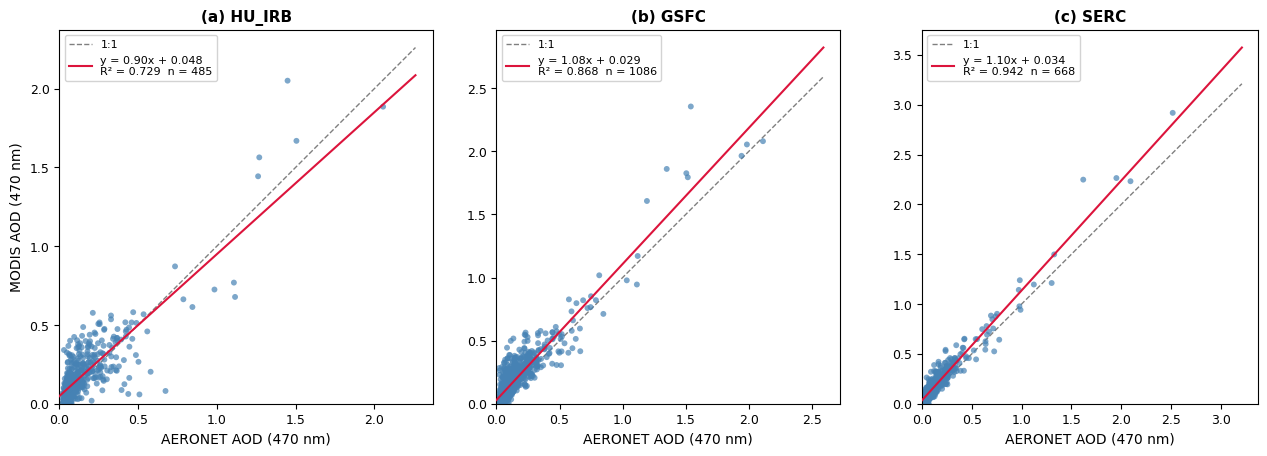

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

stations = ["HU_IRB", "GSFC", "SERC"]
labels   = ["(a)", "(b)", "(c)"]

# ── 1. Load MODIS AOD_470 (scale factor /1000) ───────────────────────────────
modis = pd.read_csv("../data/MODIS_AOD_Extraction.csv", parse_dates=["datetime"])
modis["AOD_470"] = modis["AOD_470"] / 1000
modis = modis.dropna(subset=["AOD_470"]).sort_values("datetime")

# ── 2. Load AERONET raw, interpolate to 470 nm, hourly average ───────────────
FILL = -999
matched = []

for site in stations:
    ae = pd.read_csv(f"../data/{site}/{site}_AOD20_combined.csv", low_memory=False)

    ae["datetime"] = pd.to_datetime(
        ae["Date(dd:mm:yyyy)"] + " " + ae["Time(hh:mm:ss)"],
        format="%d:%m:%Y %H:%M:%S"
    )

    ae = ae[["datetime", "AOD_440nm", "440-675_Angstrom_Exponent"]].copy()
    ae.replace(FILL, np.nan, inplace=True)
    ae.dropna(subset=["AOD_440nm", "440-675_Angstrom_Exponent"], inplace=True)
    ae = ae[ae["datetime"].dt.year.between(2021, 2025)]

    # Interpolate AERONET AOD_440 → AOD_470
    ae["AOD_470"] = ae["AOD_440nm"] * ((470 / 440) ** -ae["440-675_Angstrom_Exponent"])

    # Hourly average
    ae["hour"] = ae["datetime"].dt.floor("1h")
    ae_hourly = (
        ae.groupby("hour")["AOD_470"]
        .mean()
        .reset_index()
        .rename(columns={"hour": "datetime"})
    )

    # Match nearest AERONET hourly avg within ±60 min of each MODIS overpass
    modis_site = modis[modis["station"] == site].copy()
    merged = pd.merge_asof(
        modis_site.sort_values("datetime"),
        ae_hourly.sort_values("datetime"),
        on="datetime",
        suffixes=("_modis", "_aeronet"),
        direction="nearest",
        tolerance=pd.Timedelta(minutes=60)
    )
    merged["station"] = site
    matched.append(merged)

df_all = pd.concat(matched, ignore_index=True).dropna(subset=["AOD_470_modis", "AOD_470_aeronet"])

# ── 3. Scatter plot 1×3 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, site, label in zip(axes, stations, labels):
    sub = df_all[df_all["station"] == site]
    x = sub["AOD_470_aeronet"].values   # AERONET → x-axis
    y = sub["AOD_470_modis"].values     # MODIS   → y-axis

    ax.scatter(x, y, s=18, color="steelblue", alpha=0.7, edgecolors="none", zorder=2)

    lim = max(x.max(), y.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.5, zorder=1, label="1:1")

    if len(x) >= 2:
        slope, intercept, r, _, _ = stats.linregress(x, y)
        x_fit = np.linspace(0, lim, 200)
        ax.plot(x_fit, slope * x_fit + intercept, color="crimson", linewidth=1.5, zorder=3,
                label=f"y = {slope:.2f}x + {intercept:.3f}\nR² = {r**2:.3f}  n = {len(x)}")
        ax.legend(fontsize=8, frameon=True, framealpha=0.85, loc="upper left")

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("AERONET AOD (470 nm)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("MODIS AOD (470 nm)", fontsize=10)
    ax.set_title(f"{label} {site}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
# plt.savefig("../data/MODIS_AERONET_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
